In [69]:
import pandas as pd
import numpy as np

data_dir = "../../data/raw"

cusotmers = pd.read_csv(data_dir + "/customers.csv")
orders = pd.read_csv(data_dir + "/orders.csv")
products = pd.read_csv(data_dir + "/products.csv")
order_items = pd.read_csv(data_dir + "/order_items.csv")

orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   order_id        300 non-null    int64
 1   customer_id     300 non-null    int64
 2   order_date      300 non-null    str  
 3   payment_method  300 non-null    str  
 4   order_status    300 non-null    str  
dtypes: int64(2), str(3)
memory usage: 11.8 KB


In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

installed_fonts = {font.name for font in font_manager.fontManager.ttflist}

font_candidates = ["Malgun Gothic", "AppleGothic", "Apple SD Gothic Neo", "Noto Sans CJK KR", "NanumGothic"]

korean_font = next(
    (name for name in font_candidates if name in installed_fonts), None
)
available_fonts = set(font_candidates).intersection(installed_fonts)

if korean_font:
    plt.rcParams["font.family"] = korean_font
    plt.rcParams["axes.unicode_minus"] = "False"

print("찾은 폰트 :", korean_font)
print("설치된 폰트 목록:", available_fonts)

찾은 폰트 : Malgun Gothic
설치된 폰트 목록: {'Malgun Gothic'}


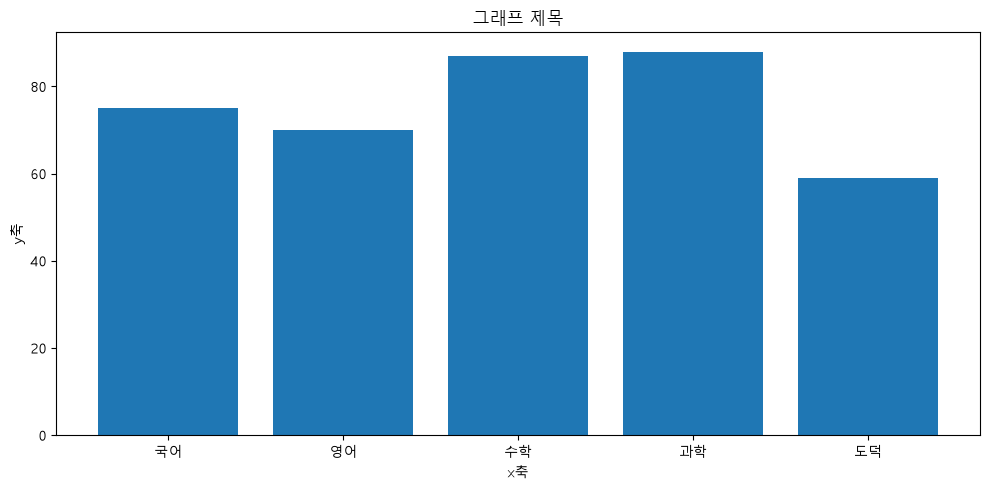

In [29]:
x_data = ["국어","영어","수학","과학","도덕"]
y_data = [75,70,87,88,59]

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x_data, y_data)
ax.set_title("그래프 제목")
ax.set_xlabel("x축")
ax.set_ylabel("y축")
ax.set_ylim(bottom=0)

fig.tight_layout()

fig.savefig(
    "graph.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [ ]:
data_dir = "../../data/processed"

cusotmers_cleaned = pd.read_csv(data_dir + "/customers_clean.csv")
orders_cleaned = pd.read_csv(data_dir + "/orders_clean.csv")
products_cleaned = pd.read_csv(data_dir + "/products_clean.csv")
order_items_cleaned = pd.read_csv(data_dir + "/order_items_clean.csv")



In [35]:
df_visualization = pd.read_csv(data_dir + "/visualization.csv")
df_visualization.head()

,order_item_id,order_id,customer_id,product_id,order_date,order_month,order_dayofweek,payment_method,order_status,gender,...,product_name,category,price,quantity,unit_price,line_total,order_match,product_match,customer_match,merge_valid
0,1,1,144.0,39,2026-07-12,2026-07,Sunday,naver_pay,completed,F,...,뷰티 상품 039,뷰티,172000.0,2.0,172000.0,344000.0,True,True,True,True
1,2,2,149.0,26,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,뷰티 상품 026,뷰티,79000.0,4.0,79000.0,316000.0,True,True,True,True
2,3,2,149.0,46,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,생활용품 상품 046,생활용품,87000.0,3.0,87000.0,261000.0,True,True,True,True
3,4,2,149.0,80,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,패션 상품 080,패션,187000.0,1.0,187000.0,187000.0,True,True,True,True
4,5,2,149.0,91,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,전자기기 상품 091,전자기기,125000.0,5.0,125000.0,625000.0,True,True,True,True


In [48]:
df_visualization.info()

<class 'pandas.DataFrame'>
RangeIndex: 752 entries, 0 to 751
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    752 non-null    int64  
 1   order_id         752 non-null    int64  
 2   customer_id      750 non-null    float64
 3   product_id       752 non-null    int64  
 4   order_date       741 non-null    str    
 5   order_month      741 non-null    str    
 6   order_dayofweek  741 non-null    str    
 7   payment_method   750 non-null    str    
 8   order_status     750 non-null    str    
 9   gender           746 non-null    str    
 10  age              746 non-null    float64
 11  city             746 non-null    str    
 12  signup_date      734 non-null    str    
 13  product_name     726 non-null    str    
 14  category         726 non-null    str    
 15  price            726 non-null    float64
 16  quantity         752 non-null    float64
 17  unit_price       752 non-nu

In [55]:
df_visualization = df_visualization.dropna()

In [56]:
category_sales = df_visualization.groupby("category", dropna=False, as_index=False).agg(
    total_amount=("line_total", sum),
    total_quantity=("quantity", sum),
).sort_values("total_amount",ascending=False)

display(category_sales)

,category,total_amount,total_quantity
9,패션,63322000.0,532.0
6,식품,45972000.0,384.0
8,전자기기,34218000.0,280.0
0,도서,27876000.0,272.0
2,뷰티,26467000.0,268.0
5,스포츠,20468000.0,253.0
4,생활용품,13835000.0,204.0
3,생활 용품,3224000.0,26.0
1,뷰 티,1026000.0,19.0
7,전자 기기,252000.0,12.0


(0.0, 66488100.0)

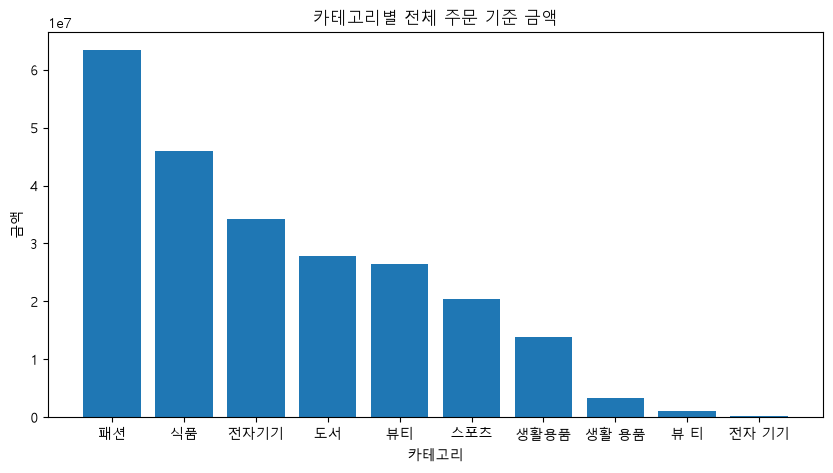

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    category_sales["category"],
    category_sales["total_amount"],
)

ax.set_title("카테고리별 전체 주문 기준 금액")
ax.set_xlabel("카테고리")
ax.set_ylabel("금액")

ax.set_ylim(bottom=0)

In [62]:
df_visualization.info()

<class 'pandas.DataFrame'>
Index: 700 entries, 0 to 751
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    700 non-null    int64  
 1   order_id         700 non-null    int64  
 2   customer_id      700 non-null    float64
 3   product_id       700 non-null    int64  
 4   order_date       700 non-null    str    
 5   order_month      700 non-null    str    
 6   order_dayofweek  700 non-null    str    
 7   payment_method   700 non-null    str    
 8   order_status     700 non-null    str    
 9   gender           700 non-null    str    
 10  age              700 non-null    float64
 11  city             700 non-null    str    
 12  signup_date      700 non-null    str    
 13  product_name     700 non-null    str    
 14  category         700 non-null    str    
 15  price            700 non-null    float64
 16  quantity         700 non-null    float64
 17  unit_price       700 non-null   

In [64]:
monthly_sales = df_visualization.groupby("order_month", as_index=False).agg(
    total_amount = ("line_total", "sum"),
    order_count = ("order_id", "nunique")
)

Text(0, 0.5, '금액')

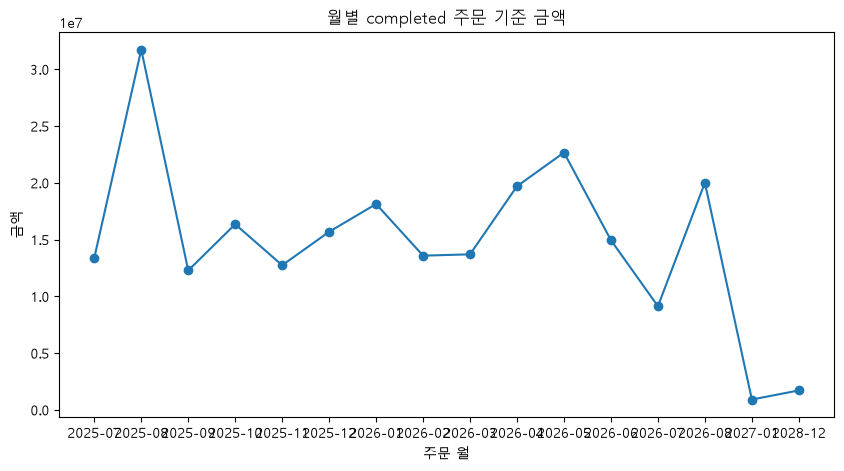

In [66]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    monthly_sales["order_month"],
    monthly_sales["total_amount"],
    marker="o",
)

ax.set_title("월별 completed 주문 기준 금액")
ax.set_xlabel("주문 월")
ax.set_ylabel("금액")

In [71]:
products.head

<bound method NDFrame.head of     product_id product_name category   price
0            1  전자기기 상품 001     전자기기  160000
1            2    도서 상품 002       도서   34000
2            3  전자기기 상품 003     전자기기  152000
3            4  생활용품 상품 004     생활용품   70000
4            5    식품 상품 005       식품  186000
..         ...          ...      ...     ...
95          96  생활용품 상품 096     생활용품  112000
96          97  전자기기 상품 097     전자기기  154000
97          98   스포츠 상품 098      스포츠   10000
98          99    뷰티 상품 099       뷰티  200000
99         100    도서 상품 100       도서  102000

[100 rows x 4 columns]>

Text(0, 0.5, '상품 수')

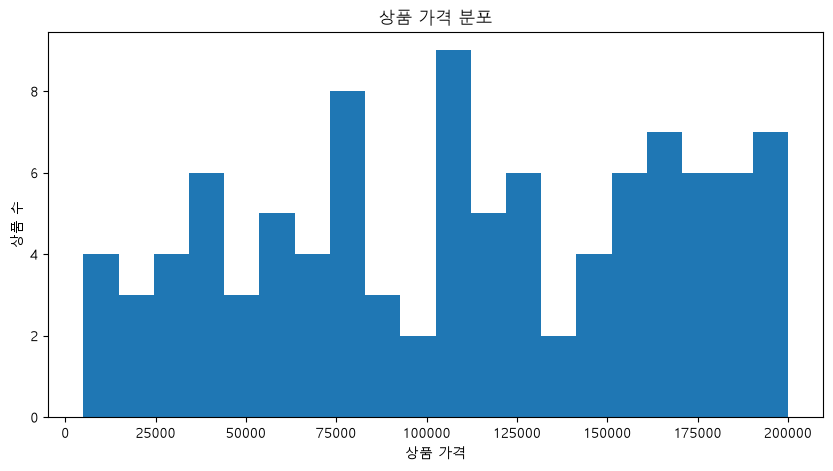

In [70]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    products["price"],
    bins=20,
)

ax.set_title("상품 가격 분포")
ax.set_xlabel("상품 가격")
ax.set_ylabel("상품 수")

Text(0, 0.5, '고객 수')

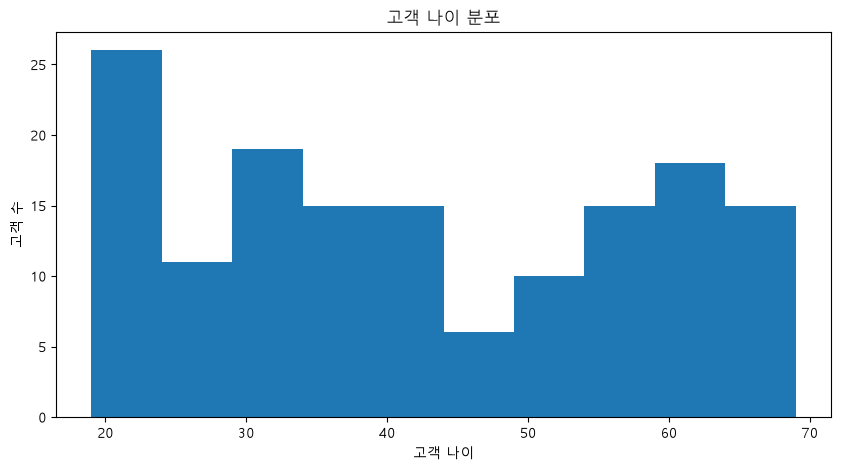

In [74]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    cusotmers["age"],
    bins=10,
)

ax.set_title("고객 나이 분포")
ax.set_xlabel("고객 나이")
ax.set_ylabel("고객 수")

In [76]:
product_sales = df_visualization.groupby("product_id", as_index=False).agg(
    total_quantity = ("quantity", "sum"),
    total_amount = ("line_total", "sum"),
)

Text(0, 0.5, 'completed 판매 수량')

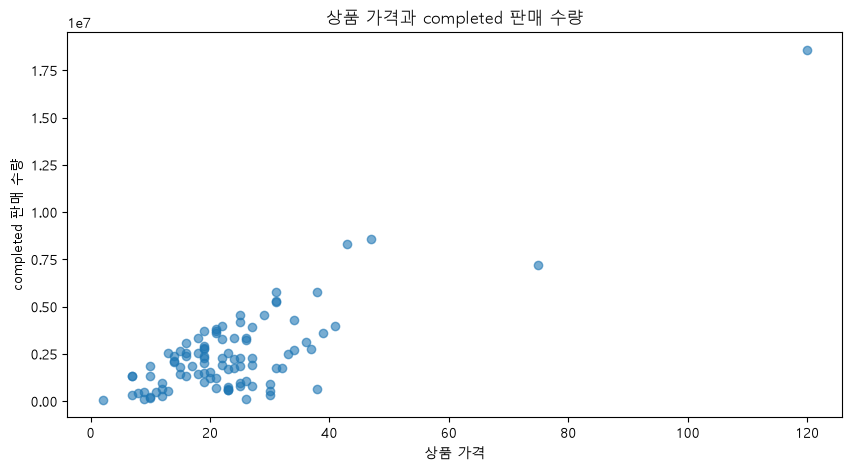

In [77]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    product_sales["total_quantity"],
    product_sales["total_amount"],
    alpha=0.6,
)
ax.set_title("상품 가격과 completed 판매 수량")
ax.set_xlabel("상품 가격")
ax.set_ylabel("completed 판매 수량")

In [85]:
customer_sales = df_visualization.groupby("customer_id",as_index=False).agg(
    total_amount = ("line_total", "sum"),
    order_count = ("order_id", "nunique"),
).sort_values("total_amount", ascending=False)

top_customers = customer_sales.head(10).reset_index(drop=True)

<BarContainer object of 10 artists>

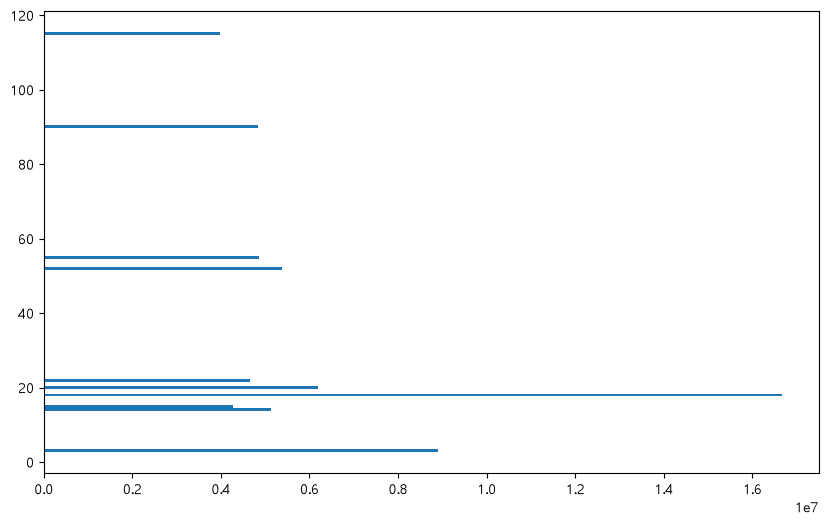

In [88]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_customers["customer_id"],
    top_customers["total_amount"],
)